# From network to federated clients — building and validating the simulator

**fedwater** · ICMC-USP master's research (continuation of the FAPESP/BEPE project)

This notebook tells the story of the simulation layer: the world it models, the
behavioural demand model, the physics that validates it, the drift mechanism,
the dependence ground truth (with a *dependence dial* and a method battery),
and finally what the federated clients actually observe.

Every figure is computed from **catalog artifacts of the Kedro pipeline** — no
simulation logic is duplicated here. Figures are exported to
`data/08_reporting/figures/` as PNG+PDF for the dissertation.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import yaml

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = PROJECT / "data/08_reporting/figures"
FIGS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.constrained_layout.use": True,
})
DENSITY_COLOR = {"low": "#0173b2", "medium": "#de8f05", "high": "#029e73"}
INCOME_MARKER = {"low": "o", "medium": "s", "high": "^"}
DISTRICT_COLOR = dict(zip(
    [f"District_{x}" for x in "ABCDE"],
    ["#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc"]))

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIGS / f"{name}.pdf", bbox_inches="tight")
    print(f"saved figures/{name}.(png|pdf)")

# ---- load the catalog once --------------------------------------------
from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession

bootstrap_project(PROJECT)
with KedroSession.create(project_path=PROJECT) as _s:
    catalog = _s.load_context().catalog

params = yaml.safe_load(open(PROJECT / "conf/base/parameters.yml"))
districts = catalog.load("districts")["districts"]
node2district = {n: d for d, nodes in districts.items() for n in nodes}
wn = catalog.load("wn_variant")
coords = {n: wn.get_node(n).coordinates for n in wn.node_name_list}

assignments = catalog.load("assignments_timeline")
demand = catalog.load("demand_series")
pressures = catalog.load("pressures")
flows = catalog.load("flows")
sensor_series = catalog.load("sensor_series")
drift = catalog.load("gt_drift_schedule"); drift["node"] = drift["node"].astype(str)
topology = catalog.load("gt_topology")
battery = catalog.load("gt_dependence_battery")
recovery = catalog.load("gt_structure_recovery")
validation = catalog.load("validation_report")
NODE_COLS = [c for c in demand.columns if c != "month"]
STEPS_DAY = int(24 / params["time"]["resolution_h"])
print(f"loaded: {len(NODE_COLS)} nodes, {demand.shape[0]:,} steps, "
      f"{len(battery)} battery rows")

[08/28/26 08:31:23] INFO     Using                                                                  ]8;id=406891;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=805833;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[08/28/26 08:31:27] INFO     No typed parameter requirements found, returning original   ]8;id=889999;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=461946;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=730537;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=526462;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Loading data from districts (YAMLDataset)...                      ]8;id=304934;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=419833;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from wn_variant (PickleDataset)...                   ]8;id=415777;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=819935;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\core.py:281 in load             │
│                                                                                                  │
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_datasets\pickle\pickle_dataset.py: │
│ 217 in load                                                                                      │
│                                                                                                  │
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\fsspec\spec.py:1310 in open              │
│                                                                                                  │
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\fsspec\implementations\local.py:201 in   │
│ _open                                                                                            │
│                                                                                                  │
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\fsspec\implementations\local.py:365 in   │
│ __init__                                                                                         │
│                                                                                                  │
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\fsspec\implementations\local.py:370 in   │
│ _open                                                                                            │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
FileNotFoundError: [Errno 2] No such file or directory: 
'C:/Users/arthu/USPy/10_Mestrado/experiments/fedWater/data/02_intermediate/wn_variant.pkl'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py:1058 in load    │
│                                                                                                  │
│ c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\core.py:288 in load             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
DatasetError: Failed while loading data from dataset 
kedro_datasets.pickle.pickle_dataset.PickleDataset(filepath=PurePosixPath('C:/Users/arthu/USPy/10_Mestrado/experime
nts/fedWater/data/02_intermediate/wn_variant.pkl'), backend='pickle', protocol='file', load_args={}, save_args={}).
[Errno 2] No such file or directory: 
'C:/Users/arthu/USPy/10_Mestrado/experiments/fedWater/data/02_intermediate/wn_variant.pkl'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:42                                                                                   │
│                                                                                                  │
│   39 params = yaml.safe_load(open(PROJECT / "conf/base/parameters.yml"))                         │
│   40 districts = catalog.load("districts")["districts"]                                          │
│   41 node2district = {n: d for d, nodes in districts.items() for n in nodes}                     │
│ ❱ 42 wn = catalog.load("wn_variant")                                                             │
│   43 coords = {n: wn.get_node(n).coordinates for n in wn.node_name_list}                         │
│   44                                                                                             │
│   45 assignments = catalog.load("assignments_timeline")                                          │
│                                                              

## Act I — The world

Graeme: 113 junctions, 164 pipes, one reservoir, partitioned into five
districts — the federated clients. Each district carries 5 sensors
(2 pressure nodes, 3 flow links).

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│    1 fig, ax = plt.subplots(figsize=(9, 6))                                                      │
│ ❱  2 for name in wn.pipe_name_list:                                                              │
│    3 │   p = wn.get_link(name)                                                                   │
│    4 │   (x1, y1), (x2, y2) = coords[p.start_node_name], coords[p.end_node_name]                 │
│    5 │   ax.plot([x1, x2], [y1, y2], color="0.75", lw=0.8, zorder=1)                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'wn' is not defined

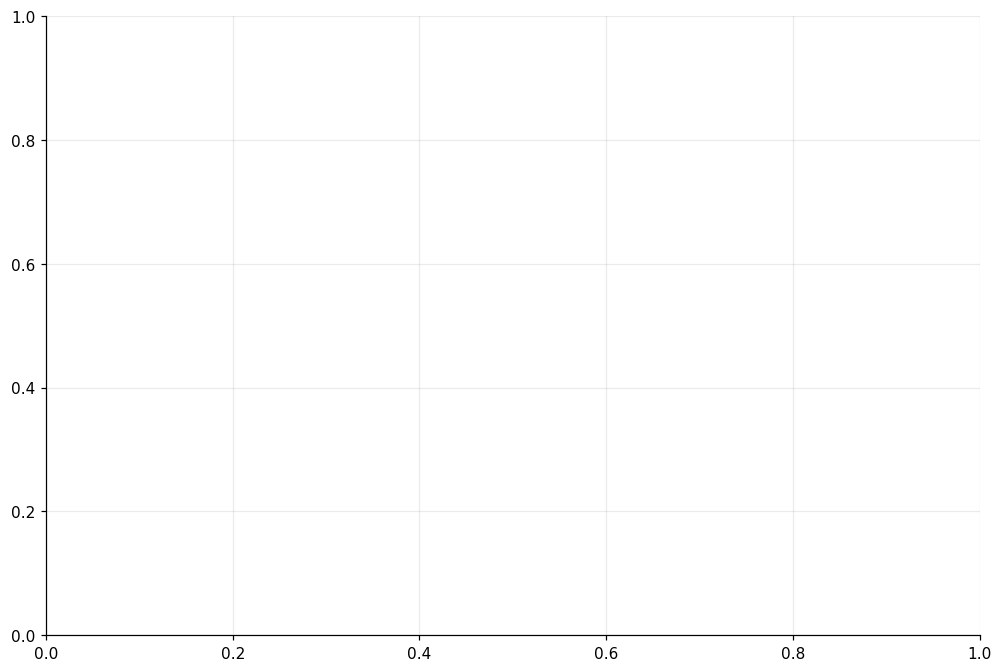

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))
for name in wn.pipe_name_list:
    p = wn.get_link(name)
    (x1, y1), (x2, y2) = coords[p.start_node_name], coords[p.end_node_name]
    ax.plot([x1, x2], [y1, y2], color="0.75", lw=0.8, zorder=1)
for n in wn.junction_name_list:
    ax.scatter(*coords[n], s=28, color=DISTRICT_COLOR[node2district[n]], zorder=2)
res = wn.reservoir_name_list[0]
ax.scatter(*coords[res], marker="*", s=380, color="black", zorder=4, label="reservoir")
sensors_cfg = params["sensors"]
for d, cfg in sensors_cfg.items():
    for n in cfg["pressure"]:
        ax.scatter(*coords[n], marker="v", s=120, facecolor="none",
                   edgecolor="black", lw=1.4, zorder=3)
for d, c in DISTRICT_COLOR.items():
    ax.scatter([], [], color=c, label=d.replace("_", " "))
ax.scatter([], [], marker="v", facecolor="none", edgecolor="black", label="pressure sensor")
ax.legend(loc="upper left", frameon=False, fontsize=8)
ax.set_title("The stage: Graeme network, five federated districts")
ax.set_aspect("equal"); ax.axis("off")
save(fig, "fig01_network_districts")

### The urban graph, before and after drift

The requested three-channel encoding, echoing Figure 1 of the BEPE report:
**size** = monthly consumption volume, **shape** = income (○ low, □ medium,
△ high), **color** = population density. District D redevelops from
(low, low) to (high, low) between months 2 and 19.

saved figures/fig02_urban_graph_before_after.(png|pdf)
income  density
high    low        24
Name: count, dtype: int64


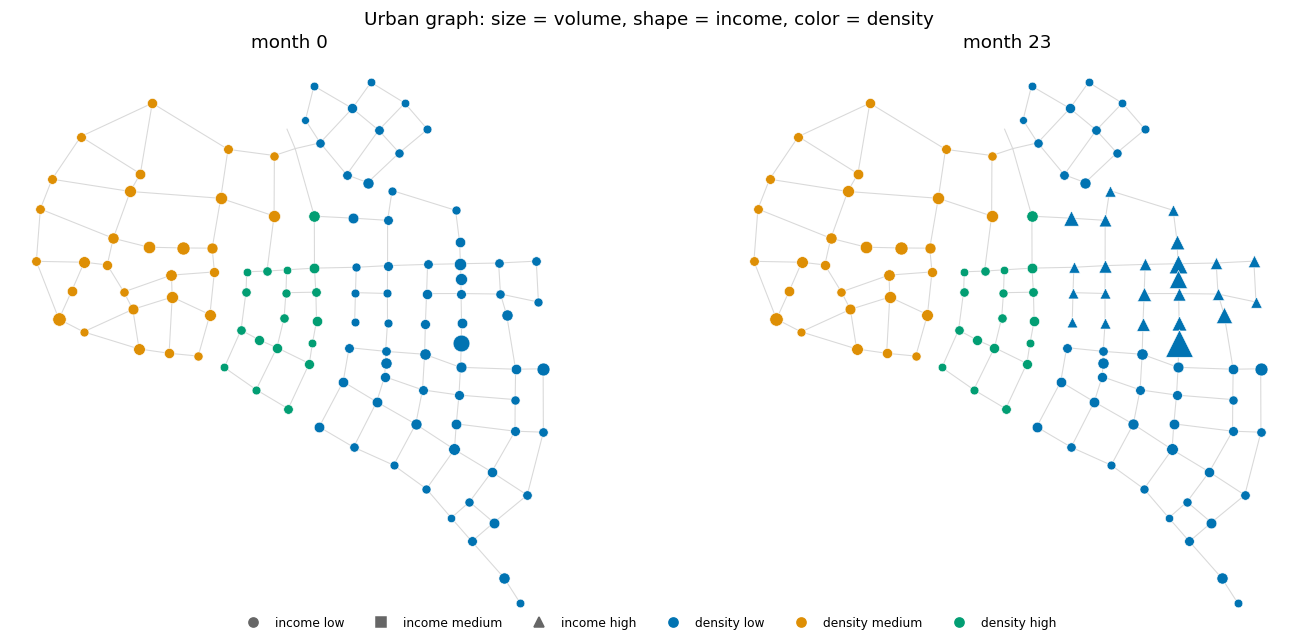

In [ ]:
snap = {m: assignments[assignments["month"] == m].drop_duplicates("node")
        for m in (0, 23)}
vmax = max(s["volume_m3_month"].max() for s in snap.values())
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, m in zip(axes, (0, 23)):
    for name in wn.pipe_name_list:
        p = wn.get_link(name)
        (x1, y1), (x2, y2) = coords[p.start_node_name], coords[p.end_node_name]
        ax.plot([x1, x2], [y1, y2], color="0.85", lw=0.7, zorder=1)
    for _, r in snap[m].iterrows():
        ax.scatter(*coords[r["node"]], s=25 + 300 * r["volume_m3_month"] / vmax,
                   marker=INCOME_MARKER[r["income"]],
                   color=DENSITY_COLOR[r["density"]],
                   edgecolor="white", lw=0.4, zorder=2)
    ax.set_title(f"month {m}"); ax.set_aspect("equal"); ax.axis("off")
handles = ([plt.Line2D([], [], ls="", marker=INCOME_MARKER[i], color="0.4",
                       label=f"income {i}") for i in INCOME_MARKER]
           + [plt.Line2D([], [], ls="", marker="o", color=DENSITY_COLOR[d],
                         label=f"density {d}") for d in DENSITY_COLOR])
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False, fontsize=8)
fig.suptitle("Urban graph: size = volume, shape = income, color = density", y=1.03)
save(fig, "fig02_urban_graph_before_after")
print(snap[23].loc[snap[23]["district"] == "District_D",
      ["income", "density"]].value_counts())

## Act II — The behavioural model

One household unit consumes on three Gaussian use-peaks over a night base;
units differ in *when* they peak (dispersion `sigma_c`, density-specific).
Summing N units has a closed form — bump width grows to
`sqrt(w0^2 + sigma_c^2)` while finite-crowd residuals shrink as `1/sqrt(N)`.
**Crowd smoothing is derived, not injected.**

saved figures/fig03_crowd_smoothing_sqrtN.(png|pdf)


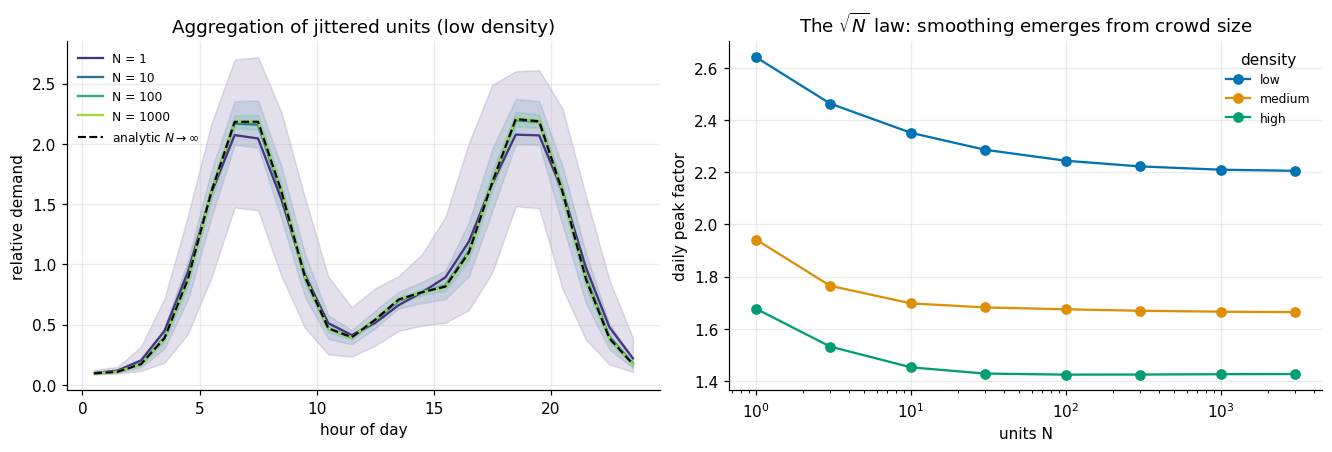

In [11]:
from fedwater.pipelines.demand_synthesis.nodes import _cohort_day_shape

pat = params["patterns"]
t = np.arange(STEPS_DAY) + 0.5
cfg_low = {k: tuple(v) for k, v in pat["peaks_by_density"]["low"].items()}
sigma_c, night = pat["peak_dispersion_h_by_density"]["low"], pat["night_by_density"]["low"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for N, col in zip([1, 10, 100, 1000], plt.cm.viridis(np.linspace(0.15, 0.85, 4))):
    reps = np.stack([_cohort_day_shape(t, cfg_low, night, sigma_c, N,
                                       np.random.default_rng(s), False, pat)
                     for s in range(60)])
    m = reps.mean(0) / reps.mean()
    axes[0].plot(t, m, color=col, label=f"N = {N}")
    axes[0].fill_between(t, np.percentile(reps / reps.mean(axis=1, keepdims=True), 10, 0),
                         np.percentile(reps / reps.mean(axis=1, keepdims=True), 90, 0),
                         color=col, alpha=0.15)
limit = _cohort_day_shape(t, cfg_low, night, sigma_c, 1e12,
                          np.random.default_rng(0), False, pat)
axes[0].plot(t, limit / limit.mean(), "k--", lw=1.4, label=r"analytic $N\to\infty$")
axes[0].set(xlabel="hour of day", ylabel="relative demand",
            title="Aggregation of jittered units (low density)")
axes[0].legend(frameon=False, fontsize=8)

Ns = [1, 3, 10, 30, 100, 300, 1000, 3000]
for dns in DENSITY_COLOR:
    cfg_d = {k: tuple(v) for k, v in pat["peaks_by_density"][dns].items()}
    pf = [np.mean([(lambda s_: s_.max() / s_.mean())(
            _cohort_day_shape(t, cfg_d, pat["night_by_density"][dns],
                              pat["peak_dispersion_h_by_density"][dns], N,
                              np.random.default_rng(s), False, pat))
          for s in range(40)]) for N in Ns]
    axes[1].semilogx(Ns, pf, "o-", color=DENSITY_COLOR[dns], label=dns)
axes[1].set(xlabel="units N", ylabel="daily peak factor",
            title=r"The $\sqrt{N}$ law: smoothing emerges from crowd size")
axes[1].legend(frameon=False, title="density", fontsize=8)
save(fig, "fig03_crowd_smoothing_sqrtN")

### A week in three densities, and the seasonal year

Left: weekday/weekend structure and density-dependent peakiness of actual
synthesized node demands. Right: monthly volumes follow the configured
seasonal cosine; District D departs from it when drift begins — by design.

saved figures/fig04_week_and_seasonality.(png|pdf)


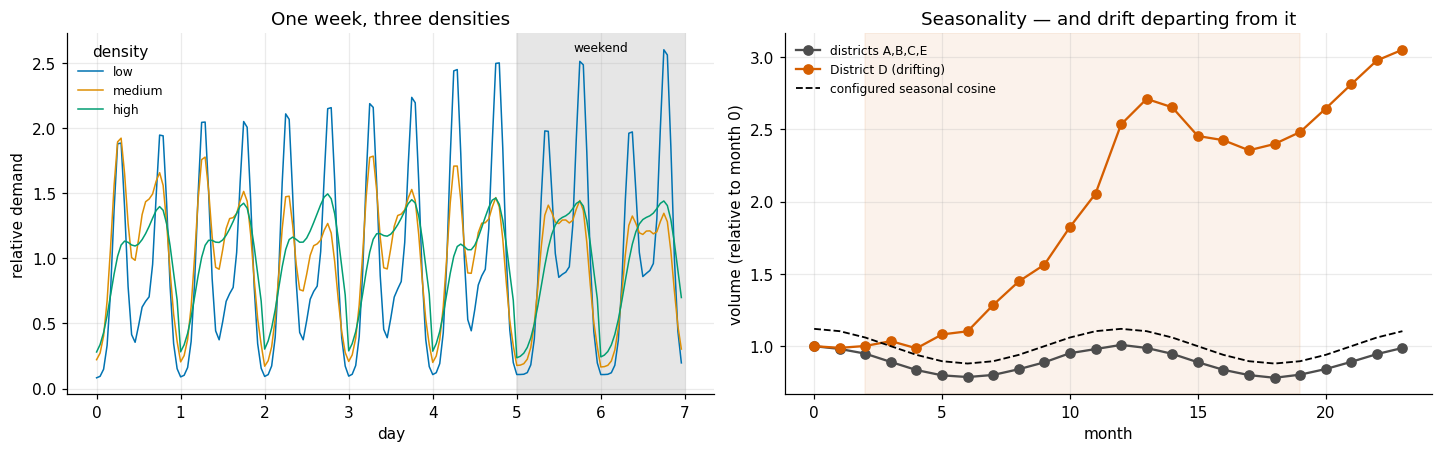

In [14]:
month0 = assignments[assignments["month"] == 0].drop_duplicates("node")
pick = {d: month0[month0["density"] == d].iloc[0]["node"] for d in DENSITY_COLOR}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
week = slice(0, 7 * STEPS_DAY)
hours = np.arange(7 * STEPS_DAY) / STEPS_DAY
for dns, node in pick.items():
    s = demand[node].iloc[week]
    axes[0].plot(hours, s / s.mean(), color=DENSITY_COLOR[dns], lw=1.0, label=dns)
axes[0].axvspan(5, 7, color="0.9", zorder=0)
axes[0].text(6, axes[0].get_ylim()[1] * 0.95, "weekend", ha="center", fontsize=8)
axes[0].set(xlabel="day", ylabel="relative demand", title="One week, three densities")
axes[0].legend(frameon=False, fontsize=8, title="density")

step_s = params["time"]["resolution_h"] * 3600
vols = demand.groupby("month")[NODE_COLS].sum() * step_s / 1e3
d_nodes = [n for n in NODE_COLS if node2district[n] == "District_D"]
rest = [n for n in NODE_COLS if n not in d_nodes]
axes[1].plot(vols.index, vols[rest].sum(1) / vols[rest].sum(1).iloc[0],
             "o-", color="0.3", label="districts A,B,C,E")
axes[1].plot(vols.index, vols[d_nodes].sum(1) / vols[d_nodes].sum(1).iloc[0],
             "o-", color=DISTRICT_COLOR["District_D"], label="District D (drifting)")
m = np.arange(24)
season = 1 + pat["seasonal_amplitude"] * np.cos(2 * np.pi * (m % 12 - pat["seasonal_peak_month"]) / 12)
axes[1].plot(m, season, "k--", lw=1.2, label="configured seasonal cosine")
axes[1].axvspan(drift["drift_month"].min(), drift["drift_month"].max(),
                color=DISTRICT_COLOR["District_D"], alpha=0.08)
axes[1].set(xlabel="month", ylabel="volume (relative to month 0)",
            title="Seasonality — and drift departing from it")
axes[1].legend(frameon=False, fontsize=8)
save(fig, "fig04_week_and_seasonality")

### Consumption sanity — do the numbers make sense?

Per-unit consumption must sit exactly on the standards table (calibration
scales *population*, never thirst), and the implied per-capita use
(assuming ~3 people per unit) must be plausible for the Brazilian urban
context: ~100–200 L/person/day for typical households, with luxury
(standard 4–5) households known to exceed 300.

In [17]:
per_node = (assignments.groupby(["month", "node", "income"])
            .agg(volume=("volume_m3_month", "first"), units=("units", "sum"))
            .reset_index())
per_node["m3_per_unit"] = per_node["volume"] / per_node["units"]
per_node["lppd"] = per_node["m3_per_unit"] * 1000 / 30 / 3  # 3 people per unit
med = per_node.groupby("income")[["m3_per_unit", "lppd"]].median()
expected = pd.Series({"low": 9.25, "medium": 13.5, "high": 29.0})
common = med.index.intersection(expected.index)
tbl = med.round(1).rename(columns={"m3_per_unit": "m3/month per unit",
                                   "lppd": "L/person/day (3 p/unit)"})
tbl["standards-table mean"] = expected
print(tbl.to_string())
assert np.allclose(med.loc[common, "m3_per_unit"], expected[common], rtol=1e-9)
bands = {"low": (80, 250), "medium": (80, 250), "high": (150, 400)}
for inc in common:
    lo, hi = bands[inc]
    assert lo <= med.loc[inc, "lppd"] <= hi, (inc, med.loc[inc, "lppd"])
print("\nOK: per-unit volume == standards table; per-capita plausible per income level")

        m3/month per unit  L/person/day (3 p/unit)  standards-table mean
income                                                                  
high                 29.0                    322.2                 29.00
low                   9.2                    102.8                  9.25

OK: per-unit volume == standards table; per-capita plausible per income level


## Act III — The physics

The hydraulic layer is where realism is *enforced*, not hoped for. Three
exhibits: the pressure field breathing between night and morning peak; the
before/after of the correctness pass (the single most important figure of the
refactor); and the operating envelope against the ABNT NBR 12218 band, with
the pipeline's own validation report.

saved figures/fig05_pressure_field.(png|pdf)


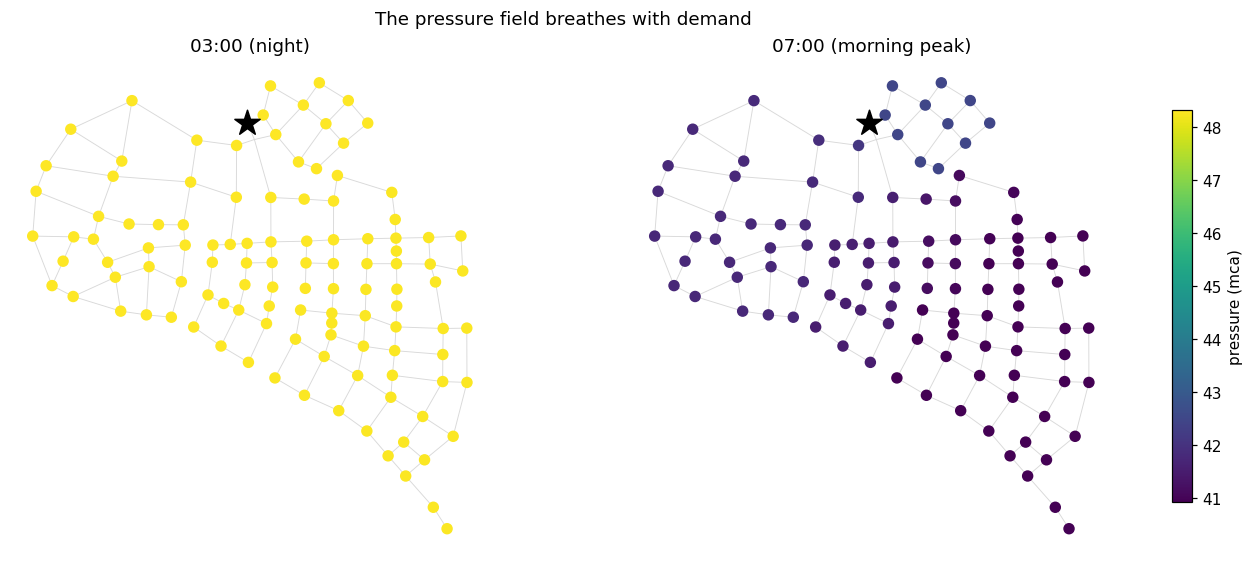

In [20]:
day0 = 10 * 30 * STEPS_DAY  # a mid-simulation day, pre... month 10
rows = {"03:00 (night)": day0 + 3, "07:00 (morning peak)": day0 + 7}
vmin = min(pressures.loc[i, NODE_COLS].min() for i in rows.values())
vmax = max(pressures.loc[i, NODE_COLS].max() for i in rows.values())
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharex=True, sharey=True)
for ax, (label, i) in zip(axes, rows.items()):
    for name in wn.pipe_name_list:
        p = wn.get_link(name)
        (x1, y1), (x2, y2) = coords[p.start_node_name], coords[p.end_node_name]
        ax.plot([x1, x2], [y1, y2], color="0.85", lw=0.6, zorder=1)
    sc = ax.scatter([coords[n][0] for n in NODE_COLS],
                    [coords[n][1] for n in NODE_COLS],
                    c=pressures.loc[i, NODE_COLS], s=42, cmap="viridis",
                    vmin=vmin, vmax=vmax, zorder=2)
    ax.scatter(*coords[wn.reservoir_name_list[0]], marker="*", s=300, c="k", zorder=3)
    ax.set_title(label); ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(sc, ax=axes, label="pressure (mca)", shrink=0.8)
fig.suptitle("The pressure field breathes with demand")
save(fig, "fig05_pressure_field")

saved figures/fig06_before_after_pressure.(png|pdf)


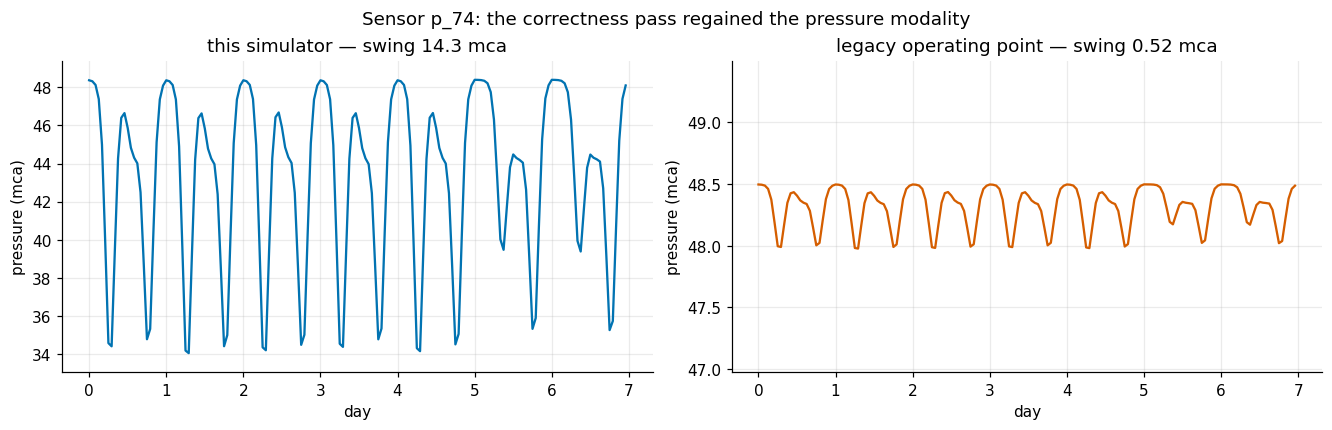

In [22]:
# Before/after: same network, legacy demand convention vs this simulator.
# Legacy delivered mean demand = inp_base * (1/24 pattern) * (0.2 multiplier)
# = inp_base/120, i.e. exactly 1/6 of our calibrated anchor (inp_base*0.05).
import copy, wntr as _wntr
wk = 7 * STEPS_DAY
wn_wk = copy.deepcopy(wn)
wn_wk.options.time.duration = wk * 3600
legacy = demand.iloc[:wk].copy(); legacy[NODE_COLS] = legacy[NODE_COLS] / 6.0
from fedwater.pipelines.hydraulics.nodes import run_hydraulics
p_leg, _, _ = run_hydraulics(wn_wk, legacy)

sensor = params["sensors"]["District_C"]["pressure"][0]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
hrs = np.arange(wk) / STEPS_DAY
axes[0].plot(hrs, pressures[sensor].iloc[:wk], color="#0173b2")
axes[1].plot(hrs, p_leg[sensor], color="#d55e00")
for ax, title, s in zip(
        axes, [f"this simulator — swing "
                f"{(pressures[sensor].iloc[:wk].max()-pressures[sensor].iloc[:wk].min()):.1f} mca",
               f"legacy operating point — swing {(p_leg[sensor].max()-p_leg[sensor].min()):.2f} mca"],
        [pressures[sensor].iloc[:wk], p_leg[sensor]]):
    ax.set(xlabel="day", ylabel="pressure (mca)", title=title)
    ax.set_ylim(s.min() - 1, s.max() + 1)
fig.suptitle(f"Sensor p_{sensor}: the correctness pass regained the pressure modality")
save(fig, "fig06_before_after_pressure")

saved figures/fig07_pressure_envelope.(png|pdf)
                   check        value  hard  passed
         V1_mass_balance 7.201216e-12  True    True
     V2_volume_exactness 4.615914e-06  True    True
       V3_pressure_floor 1.194229e+01  True    True
  V4_pressure_band_share 1.000000e+00 False    True
  V5_unit_m3_month[high] 2.900000e+01 False    True
   V5_unit_m3_month[low] 9.250000e+00 False    True
  V6_peak_factor_in_band 1.000000e+00 False    True
V6_smoothing_low_gt_high 8.256766e-01 False    True
    V6_peak_factor[high] 1.455698e+00 False    True
     V6_peak_factor[low] 2.281375e+00 False    True
  V6_peak_factor[medium] 1.635668e+00 False    True


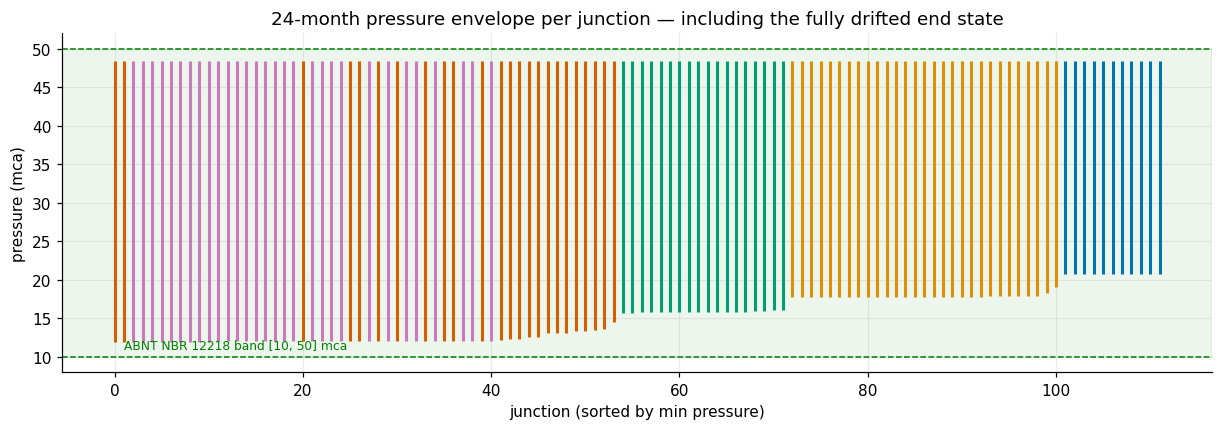

In [24]:
pmin, pmax = pressures[NODE_COLS].min(), pressures[NODE_COLS].max()
order = np.argsort(pmin.values)
fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(NODE_COLS))
ax.vlines(x, pmin.values[order], pmax.values[order],
          color=[DISTRICT_COLOR[node2district[NODE_COLS[i]]] for i in order], lw=2)
ax.axhspan(10, 50, color="green", alpha=0.07)
ax.axhline(10, color="green", ls="--", lw=1); ax.axhline(50, color="green", ls="--", lw=1)
ax.text(1, 11, "ABNT NBR 12218 band [10, 50] mca", fontsize=8, color="green")
ax.set(xlabel="junction (sorted by min pressure)", ylabel="pressure (mca)",
       title="24-month pressure envelope per junction — including the fully drifted end state")
save(fig, "fig07_pressure_envelope")
print(validation.to_string(index=False))

## Act IV — Drift, explicitly

The BEPE drift mechanism survives intact: diffusion on District D's subgraph
from a seed node, warm-up, 80% monthly growth chance, at most two neighbours
converted per month — but it is now deterministic given the seed and ships as
a **ground-truth artifact** (`gt_drift_schedule`). Four exhibits: the spatial
diffusion; a single node switching regime; what each client-level aggregate
sees; and the hinge of the whole research program — drift in D appearing in
*other districts'* sensors.

saved figures/fig08_drift_diffusion.(png|pdf)


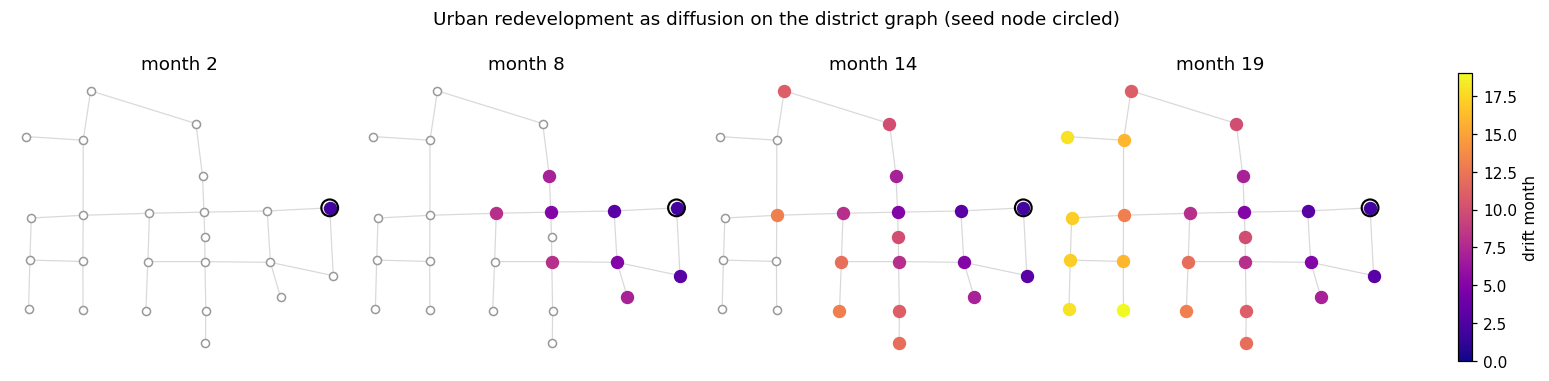

In [27]:
d_nodes_set = set(districts["District_D"])
sub_edges = [(wn.get_link(n).start_node_name, wn.get_link(n).end_node_name)
             for n in wn.pipe_name_list
             if wn.get_link(n).start_node_name in d_nodes_set
             and wn.get_link(n).end_node_name in d_nodes_set]
drift_at = drift.set_index("node")["drift_month"].to_dict()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True, sharey=True)
cmap = plt.cm.plasma
for ax, m in zip(axes, (2, 8, 14, 19)):
    for a, b in sub_edges:
        ax.plot([coords[a][0], coords[b][0]], [coords[a][1], coords[b][1]],
                color="0.85", lw=0.8, zorder=1)
    for n in d_nodes_set:
        dm = drift_at.get(n, np.inf)
        if dm <= m:
            ax.scatter(*coords[n], s=60, color=cmap(dm / 19), zorder=2)
        else:
            ax.scatter(*coords[n], s=28, facecolor="white", edgecolor="0.6", zorder=2)
    seed_n = drift.iloc[0]["node"]
    ax.scatter(*coords[seed_n], s=120, facecolor="none", edgecolor="black",
               lw=1.4, zorder=3)
    ax.set_title(f"month {m}"); ax.set_aspect("equal"); ax.axis("off")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(0, 19))
fig.colorbar(sm, ax=axes, label="drift month", shrink=0.8)
fig.suptitle("Urban redevelopment as diffusion on the district graph (seed node circled)")
save(fig, "fig08_drift_diffusion")

saved figures/fig09_drift_node_zoom.(png|pdf)


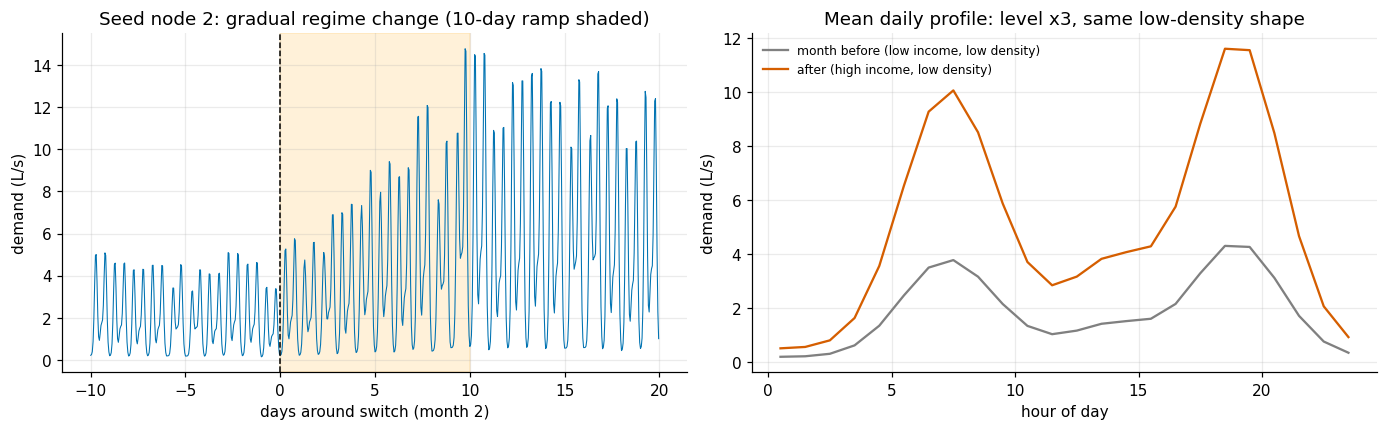

In [29]:
seed_n = drift.iloc[0]["node"]; m_switch = int(drift.iloc[0]["drift_month"])
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
win = slice((m_switch * 30 - 10) * STEPS_DAY, (m_switch * 30 + 20) * STEPS_DAY)
days_ax = np.arange(win.start, win.stop) / STEPS_DAY - m_switch * 30
axes[0].plot(days_ax, demand[seed_n].iloc[win], color="#0173b2", lw=0.7)
axes[0].axvline(0, color="k", ls="--", lw=1)
axes[0].axvspan(0, params["patterns"]["drift_ramp_days"], color="orange", alpha=0.15)
axes[0].set(xlabel=f"days around switch (month {m_switch})", ylabel="demand (L/s)",
            title=f"Seed node {seed_n}: gradual regime change "
                  f"({params['patterns']['drift_ramp_days']}-day ramp shaded)")

for m, lab, col in [(m_switch - 1, "month before (low income, low density)", "0.5"),
                    (m_switch + 2, "after (high income, low density)", "#d55e00")]:
    prof = (demand[seed_n].iloc[m * 30 * STEPS_DAY:(m + 1) * 30 * STEPS_DAY]
            .to_numpy().reshape(30, STEPS_DAY).mean(0))
    axes[1].plot(np.arange(STEPS_DAY) + 0.5, prof, color=col, label=lab)
axes[1].set(xlabel="hour of day", ylabel="demand (L/s)",
            title="Mean daily profile: level x3, same low-density shape")
axes[1].legend(frameon=False, fontsize=8)
save(fig, "fig09_drift_node_zoom")

saved figures/fig10_drift_aggregates_spillover.(png|pdf)


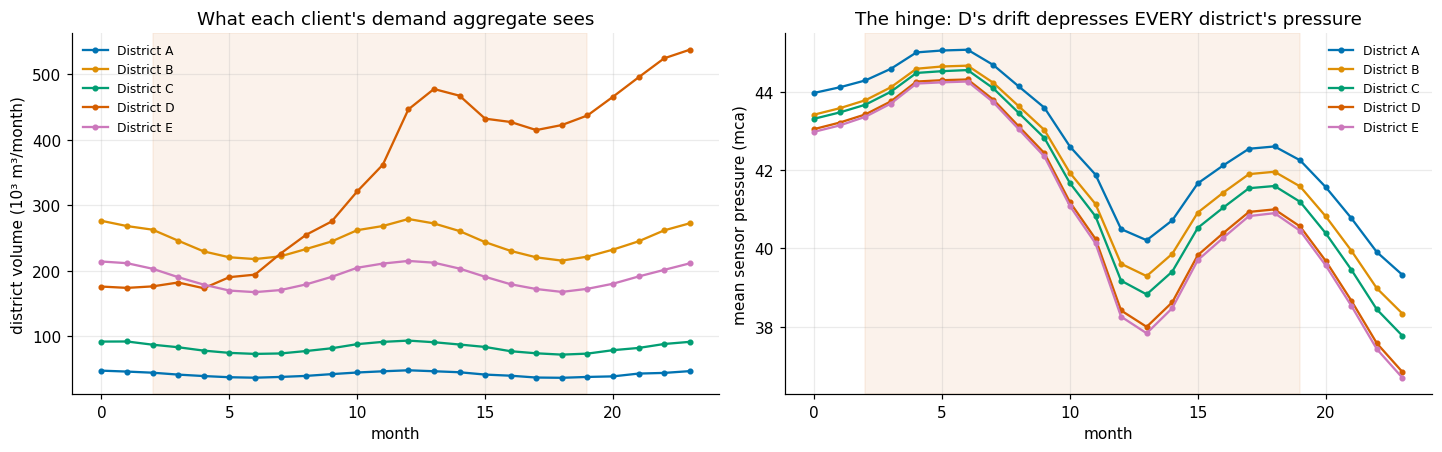

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
step_s = params["time"]["resolution_h"] * 3600
for d in DISTRICT_COLOR:
    nodes = [n for n in NODE_COLS if node2district[n] == d]
    monthly = demand.groupby("month")[nodes].sum().sum(1) * step_s / 1e3
    axes[0].plot(monthly.index, monthly / 1e3, "o-", ms=3,
                 color=DISTRICT_COLOR[d], label=d.replace("_", " "))
axes[0].axvspan(drift["drift_month"].min(), drift["drift_month"].max(),
                color=DISTRICT_COLOR["District_D"], alpha=0.08)
axes[0].set(xlabel="month", ylabel="district volume (10³ m³/month)",
            title="What each client's demand aggregate sees")
axes[0].legend(frameon=False, fontsize=8)

# the hinge: D's drift is visible in OTHER districts' pressure sensors
pobs = sensor_series[sensor_series["kind"] == "pressure"]
monthly_p = pobs.groupby(["district", "month"])["observed"].mean().unstack(0)
for d in monthly_p.columns:
    axes[1].plot(monthly_p.index, monthly_p[d], "o-", ms=3,
                 color=DISTRICT_COLOR[d], label=d.replace("_", " "))
axes[1].axvspan(drift["drift_month"].min(), drift["drift_month"].max(),
                color=DISTRICT_COLOR["District_D"], alpha=0.08)
axes[1].set(xlabel="month", ylabel="mean sensor pressure (mca)",
            title="The hinge: D's drift depresses EVERY district's pressure")
axes[1].legend(frameon=False, fontsize=8)
save(fig, "fig10_drift_aggregates_spillover")

The right panel is the entire research program in one figure: District D's
local redevelopment lowers pressures in *all five* districts through the
shared hydraulics. A drift detector that looks only at its own client cannot
distinguish "my domain changed" from "my neighbour's domain changed" —
which is exactly why dependence must be detected and quantified first.

## Act V — Dependence: ground truth, the dial, and the method battery

Structural truth first, then behaviour under the **dependence dial** (closing
inter-district boundaries in steps, ending with fully isolated districts fed
by their own sources), then the **method battery**: four tiers — linear,
nonlinear, directional, and the FL-deployable MiniRocket representation space
— each with circular-shift surrogate significance.

saved figures/fig11_topology_supergraph.(png|pdf)


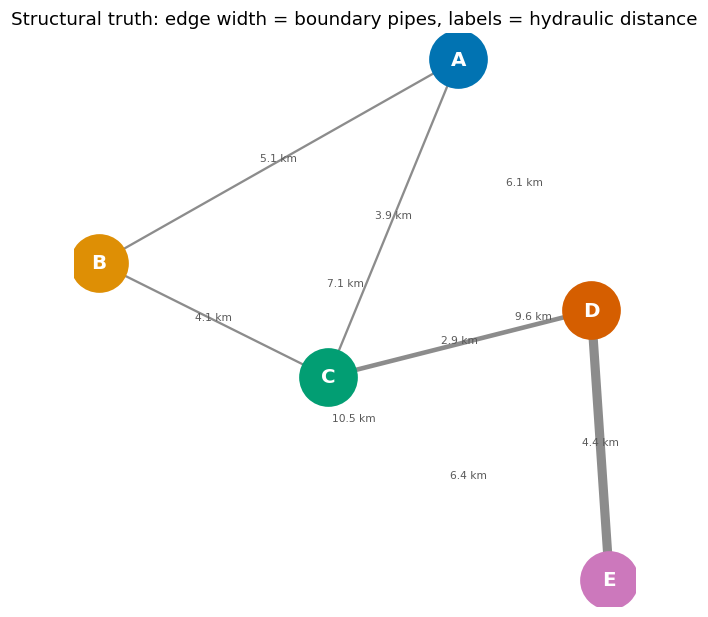

In [35]:
import networkx as nx
fig, ax = plt.subplots(figsize=(7.5, 5.5))
cent = {d: np.mean([coords[n] for n in nodes], axis=0) for d, nodes in districts.items()}
for _, r in topology.iterrows():
    a, b = r["district_a"], r["district_b"]
    if r["boundary_pipes"] > 0:
        ax.plot([cent[a][0], cent[b][0]], [cent[a][1], cent[b][1]],
                lw=1.5 * r["boundary_pipes"], color="0.55", zorder=1)
    mid = (cent[a] + cent[b]) / 2
    ax.annotate(f'{r["hydraulic_distance_m"]/1000:.1f} km', mid, fontsize=7,
                color="0.35", ha="center")
for d, c in cent.items():
    ax.scatter(*c, s=1400, color=DISTRICT_COLOR[d], zorder=2)
    ax.annotate(d[-1], c, ha="center", va="center", color="white",
                fontsize=13, weight="bold", zorder=3)
ax.set_title("Structural truth: edge width = boundary pipes, labels = hydraulic distance")
ax.set_aspect("equal"); ax.axis("off")
save(fig, "fig11_topology_supergraph")

### Turning the dial

Six pipeline runs in a scratch clone (6-month horizon, reduced surrogates,
tiers 1+4): requested `close_fraction` ∈ {0, 0.25, 0.5, 0.75, 1.0} plus the
fully `isolated` variant (boundaries closed **and** one reservoir per
district). Closures are **connectivity-preserving** — a boundary only closes
if every junction still reaches a source, as a real DMA valve plan would —
so from a single source the dial *saturates* before 100% (an early naive
version disconnected part of District D and the V3 pressure check killed the
run, exactly as designed). Each run is the real pipeline, validation included.

In [38]:
import shutil, subprocess, os, copy
SWEEP = Path("/tmp/fedwater_sweep")
if SWEEP.exists():
    shutil.rmtree(SWEEP)
shutil.copytree(PROJECT, SWEEP, ignore=shutil.ignore_patterns(
    "__pycache__", ".pytest_cache", ".ruff_cache", "notebooks", "02_intermediate"))

# NOTE: Kedro merges conf/local over conf/base DESTRUCTIVELY at the top-level
# key, so overrides must carry FULL blocks — built here from the loaded base
# params with only the swept values changed.
variants = [("partial", f) for f in (0.0, 0.25, 0.5, 0.75, 1.0)] + [("isolated", 1.0)]
sweep_batteries, sweep_sensors = {}, {}
for variant, frac in variants:
    label = "isolated" if variant == "isolated" else f"closed_{int(frac*100)}%"
    override = {
        "time": {**params["time"], "n_months": 6},
        "scenario": {**copy.deepcopy(params["scenario"]), "n_months": 6},
        "coupling": {"variant": variant, "close_fraction": float(frac)},
        "oracle": {**copy.deepcopy(params["oracle"]),
                   "tiers": [1, 4], "n_surrogates": 30,
                   "n_surrogates_expensive": 20,
                   "minirocket": {"window_h": 24, "stride_h": 6,
                                  "n_kernels": 1000, "pca_dims": 8}},
    }
    (SWEEP / "conf/local/parameters.yml").write_text(yaml.safe_dump(override))
    env = {**os.environ, "KEDRO_LOGGING_CONFIG": ""}
    r = subprocess.run(["kedro", "run"], cwd=SWEEP, env=env,
                       capture_output=True, text=True)
    assert r.returncode == 0, r.stdout[-2000:] + r.stderr[-2000:]
    sweep_batteries[label] = pd.read_csv(SWEEP / "data/03_primary/gt_dependence_battery.csv")
    sweep_sensors[label] = pd.read_parquet(SWEEP / "data/03_primary/sensor_series.parquet")
    bnd = pd.read_csv(SWEEP / "data/03_primary/gt_boundaries.csv")
    sweep_closed = globals().setdefault("sweep_closed", {})
    sweep_closed[label] = f"{int(bnd['closed'].sum())}/{len(bnd)}"
    print(f"{label}: OK ({len(sweep_batteries[label])} battery rows, "
          f"{sweep_closed[label]} boundaries closed)")

closed_0%: OK (120 battery rows, 0/9 boundaries closed)
closed_25%: OK (120 battery rows, 2/9 boundaries closed)
closed_50%: OK (120 battery rows, 4/9 boundaries closed)
closed_75%: OK (120 battery rows, 5/9 boundaries closed)
closed_100%: OK (120 battery rows, 5/9 boundaries closed)
isolated: OK (120 battery rows, 9/9 boundaries closed)


closed_25%: OK (120 battery rows, 2/9 boundaries closed)


closed_50%: OK (120 battery rows, 4/9 boundaries closed)


closed_75%: OK (120 battery rows, 5/9 boundaries closed)


closed_100%: OK (120 battery rows, 5/9 boundaries closed)


isolated: OK (120 battery rows, 9/9 boundaries closed)


saved figures/fig12_dependence_heatmaps.(png|pdf)


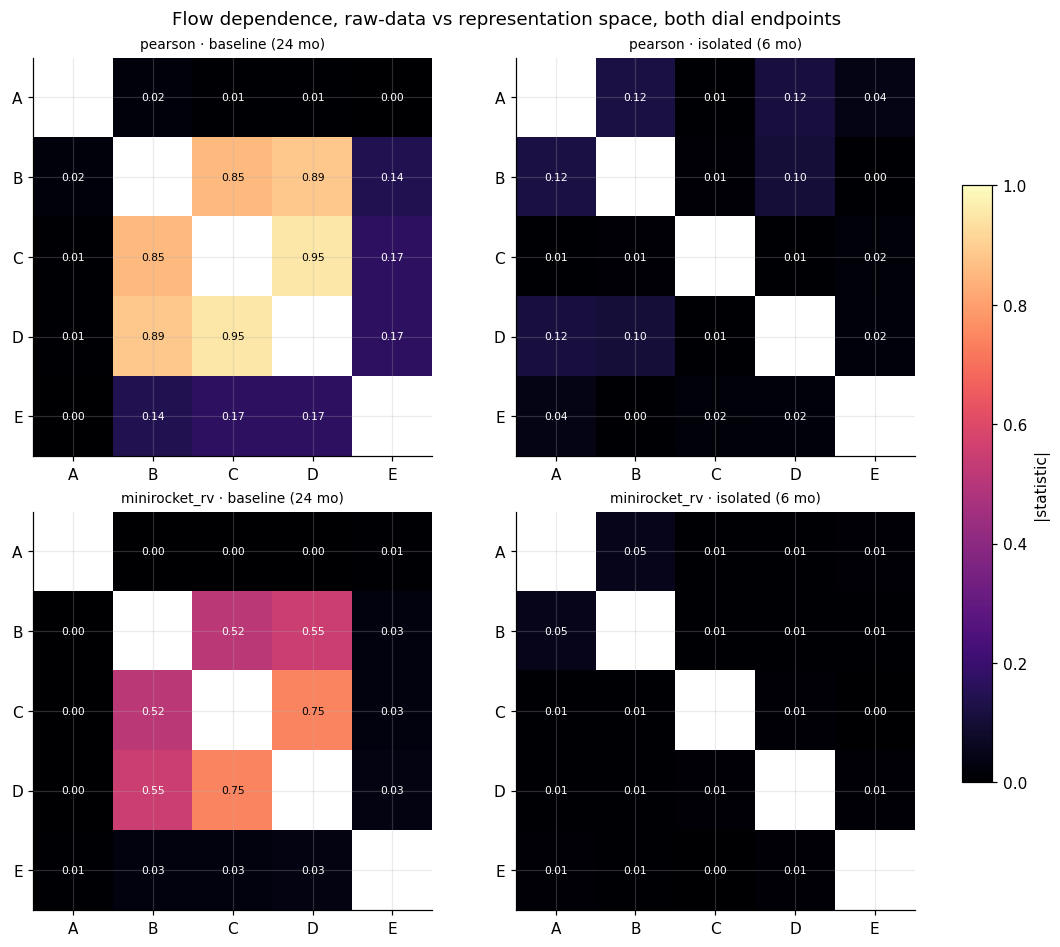

In [39]:
def pair_matrix(bat, method, kind):
    ds = [f"District_{x}" for x in "ABCDE"]
    Mx = pd.DataFrame(np.nan, index=ds, columns=ds)
    sel = bat[(bat["method"] == method) & (bat["kind"] == kind)]
    for _, r in sel.iterrows():
        Mx.loc[r["district_a"], r["district_b"]] = abs(r["statistic"])
        Mx.loc[r["district_b"], r["district_a"]] = abs(r["statistic"])
    return Mx

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))
for j, (label, bat) in enumerate([("baseline (24 mo)", battery),
                                  ("isolated (6 mo)", sweep_batteries["isolated"])]):
    for i, method in enumerate(["pearson", "minirocket_rv"]):
        Mx = pair_matrix(bat, method, "flow")
        im = axes[i, j].imshow(Mx, vmin=0, vmax=1, cmap="magma")
        axes[i, j].set_xticks(range(5), list("ABCDE"))
        axes[i, j].set_yticks(range(5), list("ABCDE"))
        axes[i, j].set_title(f"{method} · {label}", fontsize=9)
        for (a, b), v in np.ndenumerate(Mx.values):
            if a != b:
                axes[i, j].text(b, a, f"{v:.2f}", ha="center", va="center",
                                fontsize=7, color="white" if v < 0.6 else "black")
fig.colorbar(im, ax=axes, label="|statistic|", shrink=0.7)
fig.suptitle("Flow dependence, raw-data vs representation space, both dial endpoints")
save(fig, "fig12_dependence_heatmaps")

saved figures/fig13_dial_curve.(png|pdf)


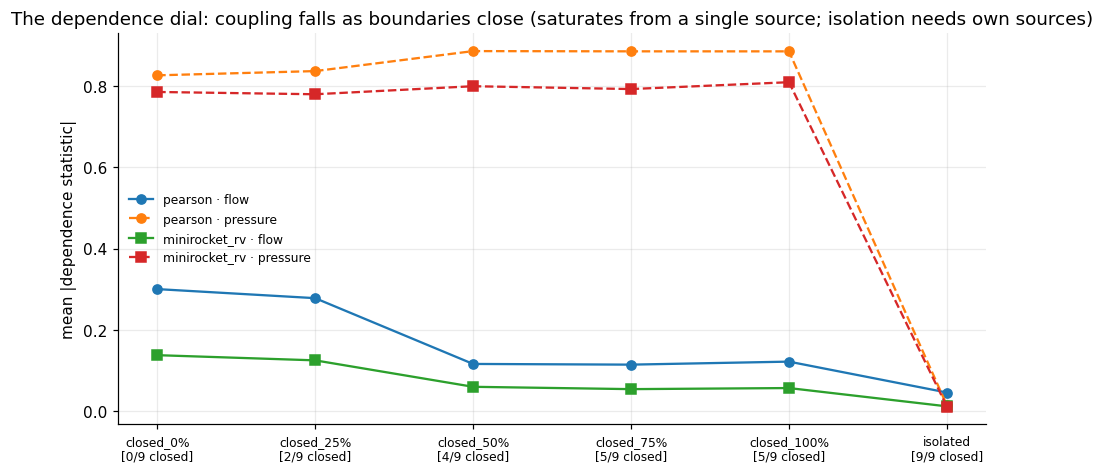

In [40]:
labels = [f"closed_{int(f*100)}%" for _, f in variants[:-1]] + ["isolated"]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for method, marker in [("pearson", "o"), ("minirocket_rv", "s")]:
    for kind, ls in [("flow", "-"), ("pressure", "--")]:
        y = [sweep_batteries[lb].query("method == @method and kind == @kind")
             ["statistic"].abs().mean() for lb in labels]
        ax.plot(range(len(labels)), y, marker=marker, ls=ls,
                label=f"{method} · {kind}")
tick_labels = [f"{lb}\n[{sweep_closed[lb]} closed]" for lb in labels]
ax.set_xticks(range(len(labels)), tick_labels, rotation=0, fontsize=8)
ax.set(ylabel="mean |dependence statistic|",
       title="The dependence dial: coupling falls as boundaries close "
             "(saturates from a single source; isolation needs own sources)")
ax.legend(frameon=False, fontsize=8)
save(fig, "fig13_dial_curve")

### The exogenous-driver confound

A methodological finding worth a section of the dissertation: with *naive*
residualization (hour-of-day profile only), even fully isolated districts
appear dependent — they share the seasonal cycle, exactly as real clients
share the weather. Month-aware residualization removes the shared slow
structure; what survives is physically transmitted dependence only.

saved figures/fig14_confound.(png|pdf)
{'naive (hour-of-day)': 'mean 0.501', 'month-aware': 'mean 0.045'}


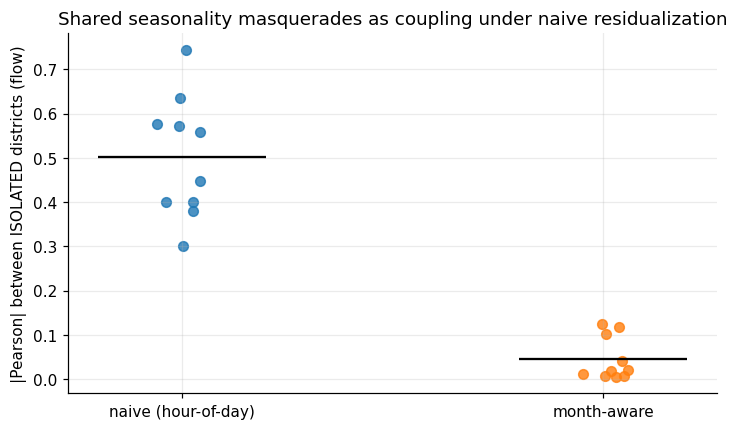

In [42]:
from fedwater.pipelines.dependence_oracle.nodes import district_signals
iso_ss = sweep_sensors["isolated"]
vals = {}
for aware in (False, True):
    sig = district_signals(iso_ss, STEPS_DAY, month_aware=aware)
    keys = sorted([d for d, k in sig if k == "flow"])
    rs = [abs(np.corrcoef(sig[(a, "flow")], sig[(b, "flow")])[0, 1])
          for i, a in enumerate(keys) for b in keys[i + 1:]]
    vals["naive (hour-of-day)" if not aware else "month-aware"] = rs

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for i, (k, rs) in enumerate(vals.items()):
    ax.scatter(np.full(len(rs), i) + np.random.uniform(-0.06, 0.06, len(rs)),
               rs, alpha=0.8, s=40)
    ax.hlines(np.mean(rs), i - 0.2, i + 0.2, color="k")
ax.set_xticks([0, 1], list(vals))
ax.set(ylabel="|Pearson| between ISOLATED districts (flow)",
       title="Shared seasonality masquerades as coupling under naive residualization")
save(fig, "fig14_confound")
print({k: f"mean {np.mean(v):.3f}" for k, v in vals.items()})

### The battery scoreboard, and directionality

Structure recovery on the baseline network (which method's pair ranking best
matches the physical topology). Honest caveat: on a single-source network the
binary "shares an open boundary" target is a *proxy* — pairs like B–D
co-fluctuate through shared trunk paths despite zero boundary pipes, so
in-variant AUROC understates every method; the dial contrast above and the
proximity correlation are the fairer reads. The standout: on pressure, where
global coupling blinds all raw-data methods, **only the MiniRocket
representation space recovers structure** — first evidence for the federated
direction. Right panel: Granger F around the drifting district — influence
flows *outward from D*, as physics demands.

saved figures/fig15_scoreboard_direction.(png|pdf)
    kind  tier                 method  auroc  spearman_vs_proximity  n_pairs
    flow     1       max_lagged_xcorr   0.64                  0.309       10
    flow     1 partial_corr_precision   0.72                  0.394       10
    flow     1                pearson   0.64                  0.309       10
    flow     1               spearman   0.64                  0.309       10
    flow     2          distance_corr   0.60                  0.297       10
    flow     2            mutual_info   0.68                  0.442       10
    flow     3              ccm_skill   0.68                  0.479       10
    flow     3              granger_f   0.60                  0.297       10
    flow     4        minirocket_dcor   0.60                  0.333       10
    flow     4          minirocket_rv   0.52                  0.127       10
pressure     1       max_lagged_xcorr   0.40                 -0.127       10
pressure     1 partial_co

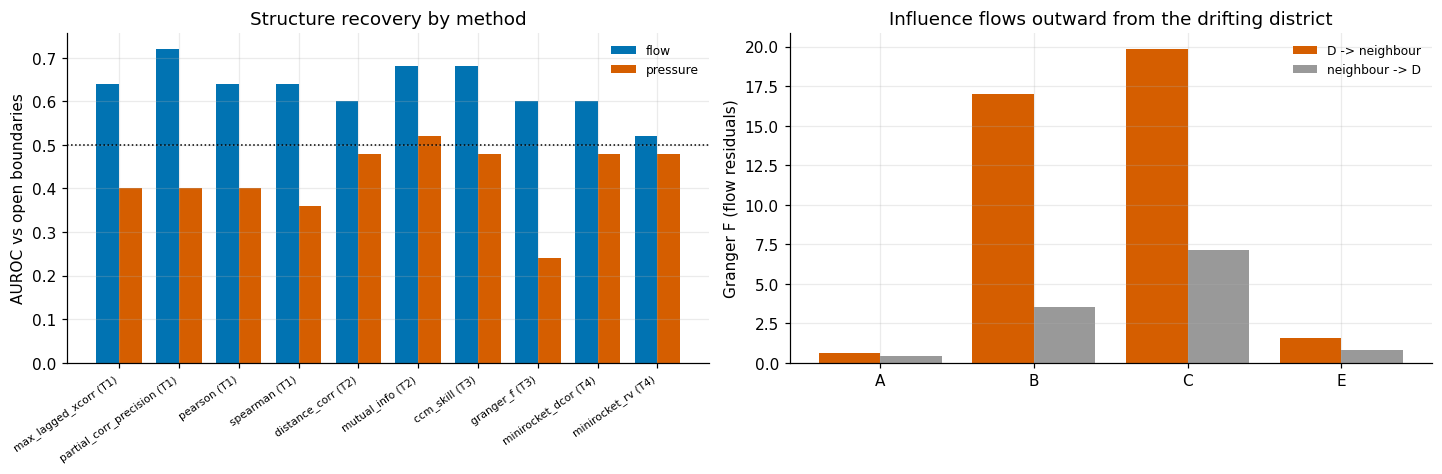

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
rec = recovery.copy()
rec["label"] = rec["method"] + " (T" + rec["tier"].astype(str) + ")"
width = 0.38
for k, (kind, col) in enumerate([("flow", "#0173b2"), ("pressure", "#d55e00")]):
    sub = rec[rec["kind"] == kind].set_index("label")["auroc"]
    order = rec[rec["kind"] == "flow"].sort_values(["tier", "method"])["label"]
    axes[0].bar(np.arange(len(order)) + (k - 0.5) * width, sub.reindex(order),
                width, color=col, label=kind)
axes[0].axhline(0.5, color="k", ls=":", lw=1)
axes[0].set_xticks(range(len(order)), order, rotation=35, ha="right", fontsize=7)
axes[0].set(ylabel="AUROC vs open boundaries", title="Structure recovery by method")
axes[0].legend(frameon=False, fontsize=8)

g = battery[(battery["method"] == "granger_f") & (battery["kind"] == "flow")]
g = g[(g["district_a"] == "District_D") | (g["district_b"] == "District_D")].copy()
g["other"] = np.where(g["district_a"] == "District_D", g["district_b"], g["district_a"])
g["outward"] = g["direction"].str.startswith("District_D->")
piv = g.pivot_table(index="other", columns="outward", values="statistic")
x = np.arange(len(piv))
axes[1].bar(x - 0.2, piv[True], 0.4, color=DISTRICT_COLOR["District_D"],
            label="D -> neighbour")
axes[1].bar(x + 0.2, piv[False], 0.4, color="0.6", label="neighbour -> D")
axes[1].set_xticks(x, [i.replace("District_", "") for i in piv.index])
axes[1].set(ylabel="Granger F (flow residuals)",
            title="Influence flows outward from the drifting district")
axes[1].legend(frameon=False, fontsize=8)
save(fig, "fig15_scoreboard_direction")
print(recovery.round(3).to_string(index=False))

## Act VI — What the federated clients see

The FL pipeline will consume exactly these per-district CSVs: a timestamp,
the authoritative month label, and five sensors degraded by the
instrumentation layer (Gaussian noise + quantization) — behaviour and
measurement are separate physical phenomena, so they are separate layers.

saved figures/fig16_client_view.(png|pdf)


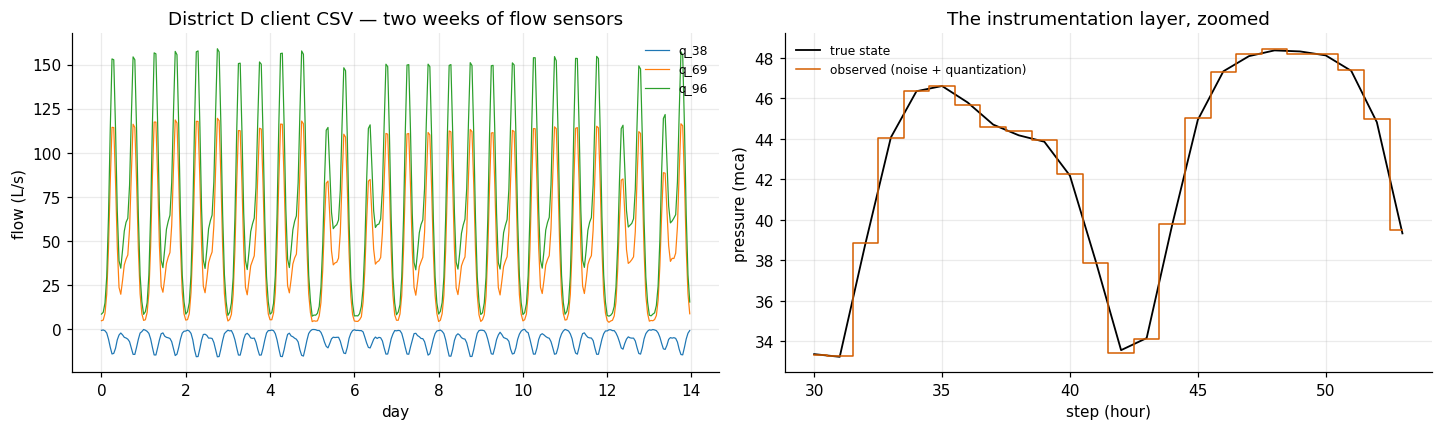

In [46]:
client_d = pd.read_csv(PROJECT / "data/07_model_output/clients/District_D.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
two_wk = slice(0, 14 * STEPS_DAY)
tt = np.arange(14 * STEPS_DAY) / STEPS_DAY
for c in [c for c in client_d.columns if c.startswith("q_")]:
    axes[0].plot(tt, client_d[c].iloc[two_wk], lw=0.8, label=c)
axes[0].set(xlabel="day", ylabel="flow (L/s)",
            title="District D client CSV — two weeks of flow sensors")
axes[0].legend(frameon=False, fontsize=8)

sens = sensor_series[(sensor_series["district"] == "District_D")
                     & (sensor_series["kind"] == "pressure")]
one = sens[sens["sensor"] == sens["sensor"].iloc[0]].iloc[30:54]
axes[1].plot(one["step"], one["value"], "k-", lw=1.2, label="true state")
axes[1].step(one["step"], one["observed"], where="mid", color="#d55e00",
             lw=1.0, label="observed (noise + quantization)")
axes[1].set(xlabel="step (hour)", ylabel="pressure (mca)",
            title="The instrumentation layer, zoomed")
axes[1].legend(frameon=False, fontsize=8)
save(fig, "fig16_client_view")

## Closing checklist — this dataset ships with its evidence

In [48]:
sig_counts = (battery[battery["p_value"] < 0.05]
              .groupby(["kind", "method"]).size().rename("significant pairs"))
print("=== validation report (hard checks raise; the run completed) ===")
print(validation.to_string(index=False))
print("\n=== battery: significant pairs at p<0.05 (circular-shift surrogates) ===")
print(sig_counts.to_string())
print(f"\nfigures exported: {sorted(p.name for p in FIGS.glob('*.png'))}")

=== validation report (hard checks raise; the run completed) ===
                   check        value  hard  passed
         V1_mass_balance 7.201216e-12  True    True
     V2_volume_exactness 4.615914e-06  True    True
       V3_pressure_floor 1.194229e+01  True    True
  V4_pressure_band_share 1.000000e+00 False    True
  V5_unit_m3_month[high] 2.900000e+01 False    True
   V5_unit_m3_month[low] 9.250000e+00 False    True
  V6_peak_factor_in_band 1.000000e+00 False    True
V6_smoothing_low_gt_high 8.256766e-01 False    True
    V6_peak_factor[high] 1.455698e+00 False    True
     V6_peak_factor[low] 2.281375e+00 False    True
  V6_peak_factor[medium] 1.635668e+00 False    True

=== battery: significant pairs at p<0.05 (circular-shift surrogates) ===
kind      method          
flow      ccm_skill            6
          distance_corr       10
          granger_f            7
          max_lagged_xcorr     6
          minirocket_dcor      6
          minirocket_rv        7
          mu

**Where this leaves us.** The simulator produces physically validated,
seed-reproducible datasets with drift and dependence ground truth as
first-class artifacts; the battery establishes the centralized upper bound;
and the Tier-4 result — a shared, training-free representation space that
recovers structure where raw-data methods fail — is the bridge to the
federated dependence detector of W05–W07. Next stop: the FL pipeline.